# Imports

In [1]:
from __future__ import absolute_import, division, print_function, unicode_literals

%load_ext autoreload
%autoreload 2

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
%matplotlib inline
%config InlineBackend.figure_format = 'retina'  # adapt plots for retina displays

from IPython.core.debugger import set_trace

In [2]:
import os
import utils
from tqdm.notebook import tqdm as tqdm_notebook
from sklearn.model_selection import train_test_split
import multiprocessing
import json

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader

In [4]:
import datasets, models, interpretation

# Load model, dataset and brain area masks

In [5]:
!ls

3D-TAME			     interpretation.py	small-dataset.ipynb
data			     LICENSE		softmax-output_state-dict.pt
datasets.py		     logs		training.ipynb
figures			     models.py		train_tame.ipynb
interpretation-mri.ipynb     __pycache__	utils.py
interpretation-photos.ipynb  README.md		wandb


In [6]:
net = models.ClassificationModel3D()
net.load_state_dict(torch.load('softmax-output_state-dict.pt'))

<All keys matched successfully>

In [7]:
# Important: Set model to eval before using any interpretation methods
net.eval();

In [8]:
# Load the data table with all 1.5 Tesla MRI scans from ADNI.
df = datasets.load_data_table_15T()

Loading dataframe for data/ADNI/ADNI_tables/customized/DxByImgClean_CompleteAnnual2YearVisitList_1_5T.csv
Found 1590 images in table
Filtered out 2 of 1590 images because of failed preprocessing
Filtered out 0 of 1588 images because of missing files
Filtered out 619 of 1588 images that were MCI
Final dataframe contains 969 images from 344 patients



In [9]:
# Patient-wise train-test-split.
# Select a number of patients for each class, put all their images in the test set 
# and all other images in the train set. This is the split that is used in the paper to produce the heatmaps.
test_patients_per_class = 30

patients_AD = df[df['DX'] == 'Dementia']['PTID'].unique()
patients_CN = df[df['DX'] == 'CN']['PTID'].unique()
patients_CN = list(filter(lambda p: p not in patients_AD, patients_CN))  # patients that have both a CN and an AD scan should belong to the AD group

patients_AD_train, patients_AD_test = train_test_split(patients_AD, test_size=test_patients_per_class, random_state=0)
patients_CN_train, patients_CN_test = train_test_split(patients_CN, test_size=test_patients_per_class, random_state=0)

patients_train = np.concatenate([patients_AD_train, patients_CN_train])
patients_test = np.concatenate([patients_AD_test, patients_CN_test])

In [10]:
train_dataset, test_dataset = datasets.build_datasets(df, patients_train, patients_test, normalize=True)

         Images    -> AD    -> CN    Patients    -> AD    -> CN
-----  --------  -------  -------  ----------  -------  -------
All         969      475      494         344      193      151
Train       794      399      395         284      163      121
Val         175       76       99          60       30       30

Calculating mean and std for normalization:


  0%|          | 0/200 [00:00<?, ?it/s]

0.0 605.9130752062255 None None


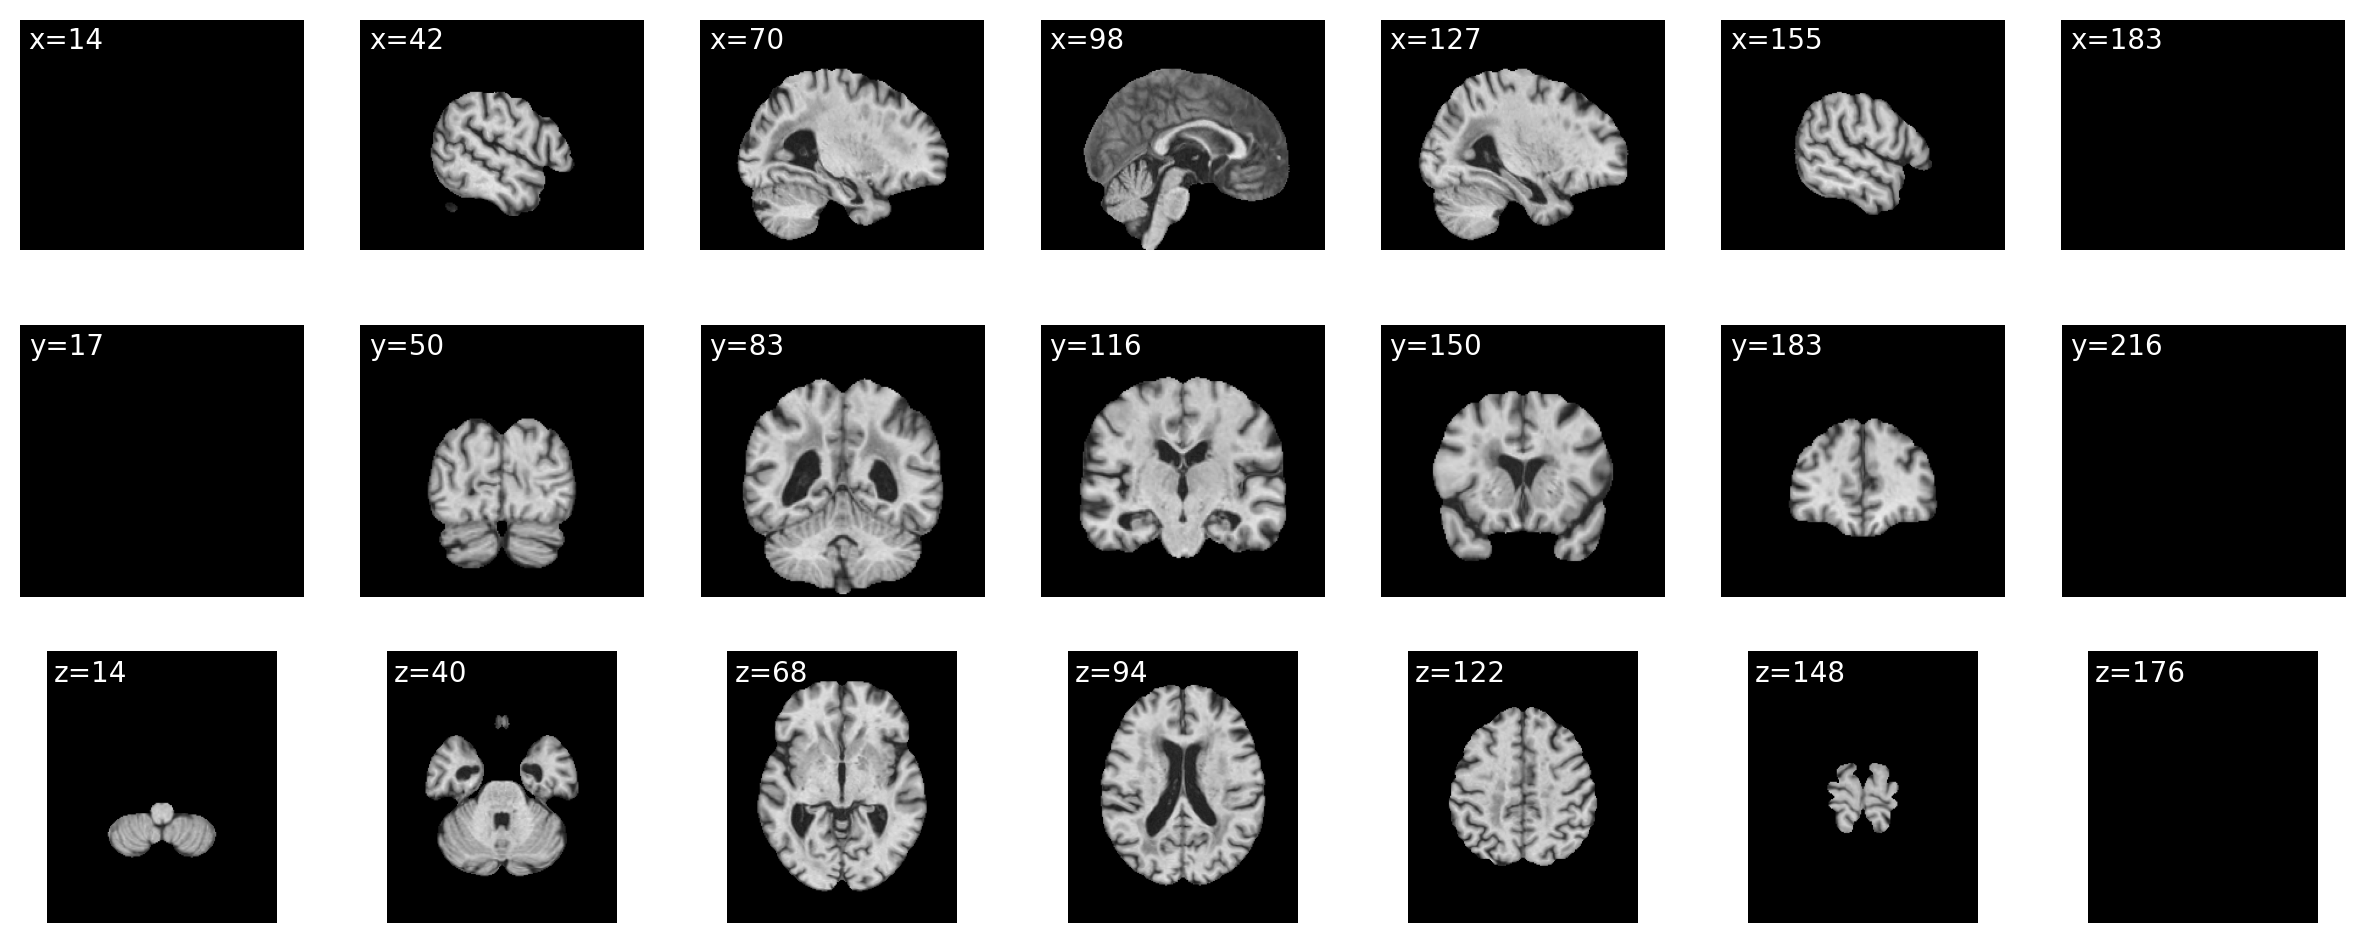

In [11]:
# Plot one MRI scan from the dataset, first without normalization...
i = 0
utils.plot_slices(train_dataset.get_raw_image(i))

tensor(-1.8865) tensor(4.1926) None None


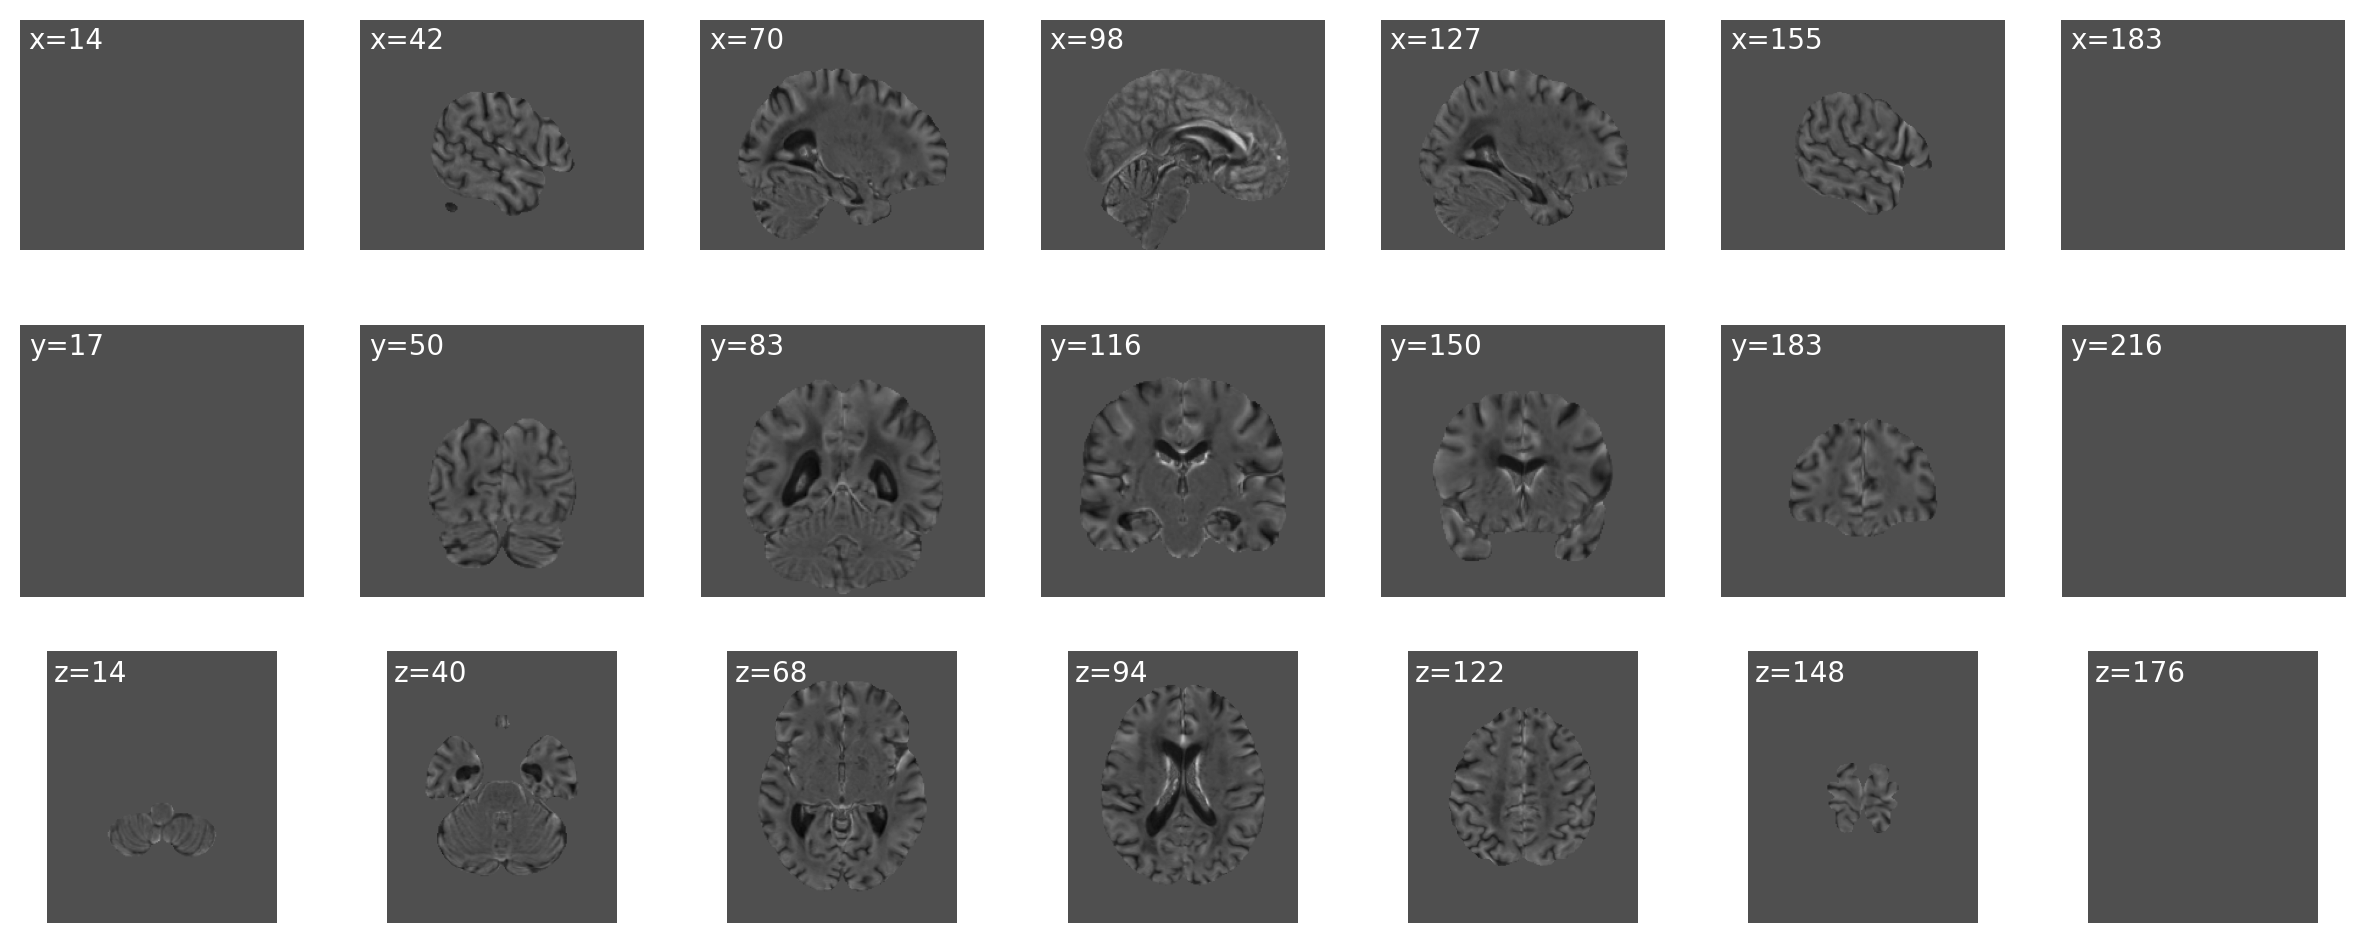

In [12]:
# ... and then with normalization, i.e. the way the network sees it.
utils.plot_slices(train_dataset[i][0][0])

# Build TAME model

In [22]:
from tame.utilities.pl_module import TAMELIT
import lightning.pytorch as pl
from lightning.pytorch.loggers import WandbLogger, CSVLogger

version = "3D-TAME"
model = net
layers = [
    'max_pool3d_1',
    'max_pool3d_2',
    'max_pool3d_3'
]
epochs = 8

pl_model = TAMELIT(
    model_name="ADNI_CNN",
    model=model,
    input_dim=train_dataset[0][0].unsqueeze(0).shape,
    stats=(train_dataset.mean, train_dataset.std), # type: ignore
    layers=layers,
    attention_version=version,
    train_method="new",
    lr=0.001,
    epochs=epochs,
    num_classes=2,
    eval_length="short"
)

train_loader, test_loader = datasets.build_loaders(train_dataset, test_dataset)
wandb_logger = WandbLogger(project="3D-TAME")
trainer = pl.Trainer(
    enable_checkpointing=True,
    max_epochs=epochs,
    logger=wandb_logger
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [23]:
torch.set_float32_matmul_precision('medium')

In [24]:
trainer.fit(pl_model, train_loader)

/home/ntrougkas/Documents/3D-TAME/.venv/lib/python3.8/site-packages/lightning/pytorch/trainer/configuration_validator.py:74: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
/home/ntrougkas/Documents/3D-TAME/.venv/lib/python3.8/site-packages/lightning/pytorch/loggers/wandb.py:389: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
/home/ntrougkas/Documents/3D-TAME/.venv/lib/python3.8/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:630: Checkpoint directory ./3D-TAME/92ah6jpt/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.

  | Name           | Type               | Params
------------------------------------------------------
0 | generic        | Generic            | 855 K 
1 | train_accuracy | MulticlassAccur

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=8` reached.


In [25]:
# trainer.logger = CSVLogger("logs", name="3D-TAME")
trainer.test(pl_model, test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         AD 100%             4.616366386413574
         AD 15%              5.651134967803955
         AD 50%              7.093224048614502
         IC 100%            19.428571701049805
         IC 15%             48.000003814697266
         IC 50%                    36.0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'AD 100%': 4.616366386413574,
  'IC 100%': 19.428571701049805,
  'AD 50%': 7.093224048614502,
  'IC 50%': 36.0,
  'AD 15%': 5.651134967803955,
  'IC 15%': 48.000003814697266}]

test that AD and IC are working correctly

In [ ]:
# Set up a binary mask for each brain area based on the AAL atlas.
# This is required for brain area occlusion and to determine the relevance per area.
# The AAL atlas can for example be retrieved from here: https://github.com/neurolabusc/MRIcron/blob/master/templates/aal.nii.gz
brain_map = utils.load_nifti('data/aal.nii.gz')
brain_areas = np.unique(brain_map)[1:]  # omit background

area_masks = []
for area in tqdm_notebook(brain_areas):
    area_mask = np.zeros_like(brain_map)
    area_mask[brain_map == area] = 1
    area_mask = utils.resize_image(area_mask, test_dataset.image_shape(), interpolation=0)
    area_masks.append(area_mask)

area_names = ['Precentral_L', 'Precentral_R', 'Frontal_Sup_L', 'Frontal_Sup_R', 'Frontal_Sup_Orb_L', 'Frontal_Sup_Orb_R', 'Frontal_Mid_L', 'Frontal_Mid_R', 'Frontal_Mid_Orb_L', 'Frontal_Mid_Orb_R', 'Frontal_Inf_Oper_L', 'Frontal_Inf_Oper_R', 'Frontal_Inf_Tri_L', 'Frontal_Inf_Tri_R', 'Frontal_Inf_Orb_L', 'Frontal_Inf_Orb_R', 'Rolandic_Oper_L', 'Rolandic_Oper_R', 'Supp_Motor_Area_L', 'Supp_Motor_Area_R', 'Olfactory_L', 'Olfactory_R', 'Frontal_Sup_Medial_L', 'Frontal_Sup_Medial_R', 'Frontal_Med_Orb_L', 'Frontal_Med_Orb_R', 'Rectus_L', 'Rectus_R', 'Insula_L', 'Insula_R', 'Cingulum_Ant_L', 'Cingulum_Ant_R', 'Cingulum_Mid_L', 'Cingulum_Mid_R', 'Cingulum_Post_L', 'Cingulum_Post_R', 'Hippocampus_L', 'Hippocampus_R', 'ParaHippocampal_L', 'ParaHippocampal_R', 'Amygdala_L', 'Amygdala_R', 'Calcarine_L', 'Calcarine_R', 'Cuneus_L', 'Cuneus_R', 'Lingual_L', 'Lingual_R', 'Occipital_Sup_L', 'Occipital_Sup_R', 'Occipital_Mid_L', 'Occipital_Mid_R', 'Occipital_Inf_L', 'Occipital_Inf_R', 'Fusiform_L', 'Fusiform_R', 'Postcentral_L', 'Postcentral_R', 'Parietal_Sup_L', 'Parietal_Sup_R', 'Parietal_Inf_L', 'Parietal_Inf_R', 'SupraMarginal_L', 'SupraMarginal_R', 'Angular_L', 'Angular_R', 'Precuneus_L', 'Precuneus_R', 'Paracentral_Lobule_L', 'Paracentral_Lobule_R', 'Caudate_L', 'Caudate_R', 'Putamen_L', 'Putamen_R', 'Pallidum_L', 'Pallidum_R', 'Thalamus_L', 'Thalamus_R', 'Heschl_L', 'Heschl_R', 'Temporal_Sup_L', 'Temporal_Sup_R', 'Temporal_Pole_Sup_L', 'Temporal_Pole_Sup_R', 'Temporal_Mid_L', 'Temporal_Mid_R', 'Temporal_Pole_Mid_L', 'Temporal_Pole_Mid_R', 'Temporal_Inf_L', 'Temporal_Inf_R', 'Cerebelum_Crus1_L', 'Cerebelum_Crus1_R', 'Cerebelum_Crus2_L', 'Cerebelum_Crus2_R', 'Cerebelum_3_L', 'Cerebelum_3_R', 'Cerebelum_4_5_L', 'Cerebelum_4_5_R', 'Cerebelum_6_L', 'Cerebelum_6_R', 'Cerebelum_7b_L', 'Cerebelum_7b_R', 'Cerebelum_8_L', 'Cerebelum_8_R', 'Cerebelum_9_L', 'Cerebelum_9_R', 'Cerebelum_10_L', 'Cerebelum_10_R', 'Vermis_1_2', 'Vermis_3', 'Vermis_4_5', 'Vermis_6', 'Vermis_7', 'Vermis_8', 'Vermis_9', 'Vermis_10']

# Merge left and right areas.
merged_area_names = [name[:-2] for name in area_names[:108:2]] + area_names[108:]

In [ ]:
def get_relevance_per_area(relevance_map, normalize=True):
    relevances = np.zeros(len(area_masks))
    for i, area_mask in enumerate(area_masks):
        relevances[i] = np.sum(relevance_map * area_mask)
    if normalize:
        relevances /= relevances.sum()  # make all areas sum to 1

    # Merge left and right areas.
    merged_relevances = np.concatenate([relevances[:108].reshape(-1, 2).sum(1), relevances[108:]])

    return sorted(zip(merged_area_names, merged_relevances), key=lambda x: x[1], reverse=True)

# Relevance heatmaps for single images

## Raw image

In [ ]:
which = 1

image_tensor = test_dataset[which][0]
raw_image = test_dataset.get_raw_image(which)

utils.plot_slices(raw_image, num_slices=7)

## Sensitivity Analysis

In [ ]:
relevance_map_backprop = interpretation.sensitivity_analysis(net, image_tensor, cuda=True, verbose=True)

In [ ]:
utils.plot_slices(raw_image, overlay=relevance_map_backprop[0], overlay_vmax=np.percentile(relevance_map_backprop, 99.9), overlay_cmap=utils.alpha_to_red_cmap)

In [ ]:
get_relevance_per_area(relevance_map_backprop[0])[:10]

## Guided Backpropagation

In [ ]:
relevance_map_guided = interpretation.guided_backprop(net, image_tensor, cuda=True, verbose=True)

In [ ]:
utils.plot_slices(raw_image, overlay=relevance_map_guided[0], overlay_vmax=np.percentile(relevance_map_guided, 99.9))

In [ ]:
get_relevance_per_area(relevance_map_guided[0])[:10]

## Occlusion

In [ ]:
relevance_map_occlusion = interpretation.occlusion(net, image_tensor, size=40, stride=25, cuda=True, resize=True, verbose=True)

In [ ]:
utils.plot_slices(raw_image, overlay=relevance_map_occlusion, overlay_cmap=utils.alpha_to_red_cmap)

In [ ]:
utils.plot_slices(raw_image, overlay=relevance_map_occlusion, overlay_cmap=utils.alpha_to_red_cmap)

In [ ]:
get_relevance_per_area(relevance_map_occlusion)[:10]

In [ ]:
# Plot occlusion patch on image.
occluded_image = raw_image[:, 114, :].copy()
size = 40
occluded_image[50:50+size, 70:70+size] = 0
plt.imshow(occluded_image, cmap='gray')
plt.axis('off')

## Area Occlusion

In [ ]:
relevance_map_area_occlusion = interpretation.area_occlusion(net, image_tensor, area_masks, cuda=True, verbose=True)

In [ ]:
utils.plot_slices(raw_image, overlay=relevance_map_area_occlusion, overlay_cmap=utils.alpha_to_red_cmap)#, overlay_vmin=0, overlay_vmax=1)

In [ ]:
get_relevance_per_area(relevance_map_area_occlusion)[:10]

## Grad-CAM
Note: Grad-CAM doesn't work on this data. It's only included here for completeness, but I couldn't figure out if there's a bug in the implementation or if the method is not applicable to this kind of data and/or model.

In [ ]:
# TODO: Something is apparently wrong with gradcam, try to fix it. Could also simply be because feature maps of last layer are just 4x5x4, so very small.

In [ ]:
relevance_map_grad_cam = interpretation.grad_cam(net, image_tensor, cuda=True, resize=True, interpolation=0, verbose=True)

In [ ]:
utils.plot_slices(raw_image, overlay=relevance_map_grad_cam * test_dataset.std + test_dataset.mean)

In [ ]:
utils.plot_slices(raw_image, overlay=relevance_map_grad_cam)

In [ ]:
utils.plot_slices(relevance_map_grad_cam)

In [ ]:
get_relevance_per_area(relevance_map_grad_cam)[:10]

# Relevance heatmaps averaged over the dataset
Plot an average relevance map of all Alzheimer and all control patients (in the test set). These are the kind of plots that are included in the paper.

In [ ]:
# If None, average over the entire dataset, otherwise pick a number of samples.
num_samples=None

# The background over which to plot the heatmaps.
bg = test_dataset.mean

## Backpropagation

In [ ]:
avg_relevance_map_AD_backprop, avg_relevance_map_NC_backprop, avg_relevance_map_all_backprop = interpretation.average_over_dataset(interpretation.sensitivity_analysis, net, test_dataset, num_samples=num_samples, seed=0, show_progress=True, cuda=True)

In [ ]:
utils.plot_slices(bg, overlay=avg_relevance_map_AD_backprop[0], overlay_vmax=np.percentile(avg_relevance_map_AD_backprop, 99.9))

In [ ]:
get_relevance_per_area(avg_relevance_map_AD_backprop)[:10]

In [ ]:
utils.plot_slices(bg, overlay=avg_relevance_map_NC_backprop[0], overlay_vmax=np.percentile(avg_relevance_map_NC_backprop, 99.9))

In [ ]:
get_relevance_per_area(avg_relevance_map_NC_backprop)[:10]

## Guided Backpropagation

In [ ]:
avg_relevance_map_AD_guided, avg_relevance_map_NC_guided, avg_relevance_map_all_guided = interpretation.average_over_dataset(interpretation.guided_backprop, net, test_dataset, num_samples=num_samples, seed=0, show_progress=True, cuda=True)

In [ ]:
utils.plot_slices(bg, overlay=avg_relevance_map_AD_guided[0], overlay_vmax=np.percentile(avg_relevance_map_AD_guided, 99.9))

In [ ]:
get_relevance_per_area(avg_relevance_map_AD_guided)[:10]

In [ ]:
utils.plot_slices(bg, overlay=avg_relevance_map_NC_guided[0], overlay_vmax=np.percentile(avg_relevance_map_NC_guided, 99.9))

In [ ]:
get_relevance_per_area(avg_relevance_map_NC_guided)[:10]

## Occlusion

In [ ]:
avg_relevance_map_AD_occlusion, avg_relevance_map_NC_occlusion, avg_relevance_map_all_occlusion = interpretation.average_over_dataset(interpretation.occlusion, net, test_dataset, num_samples=num_samples, show_progress=True, size=40, stride=40, cuda=True)

In [ ]:
utils.plot_slices(bg, overlay=avg_relevance_map_AD_occlusion, overlay_cmap=utils.alpha_to_red_cmap)

In [ ]:
get_relevance_per_area(avg_relevance_map_AD_occlusion)[:10]

In [ ]:
utils.plot_slices(bg, overlay=avg_relevance_map_NC_occlusion, overlay_cmap=utils.alpha_to_red_cmap)

In [ ]:
get_relevance_per_area(avg_relevance_map_NC_occlusion)[:10]

## Area Occlusion

In [ ]:
avg_relevance_map_AD_area_occlusion, avg_relevance_map_NC_area_occlusion, avg_relevance_map_all_area_occlusion = interpretation.average_over_dataset(interpretation.area_occlusion, net, test_dataset, num_samples=num_samples, seed=0, show_progress=True, cuda=True, area_masks=area_masks)

In [ ]:
utils.plot_slices(bg, overlay=avg_relevance_map_AD_area_occlusion, overlay_cmap=utils.alpha_to_red_cmap)

In [ ]:
get_relevance_per_area(avg_relevance_map_AD_area_occlusion)[:10]

In [ ]:
utils.plot_slices(bg, overlay=avg_relevance_map_NC_area_occlusion)

In [ ]:
get_relevance_per_area(avg_relevance_map_NC_area_occlusion)[:10]

## Grad-CAM

In [ ]:
avg_relevance_map_AD_grad_cam, avg_relevance_map_NC_grad_cam, avg_relevance_map_all_grad_cam = average_over_dataset(grad_cam, net, val_dataset, num_samples=10, show_progress=True, resize=True, interpolation=0, cuda=True)

In [ ]:
utils.plot_slices(mask, overlay=avg_relevance_map_AD_grad_cam)

In [ ]:
get_relevance_per_area(avg_relevance_map_AD_grad_cam)[:10]

In [ ]:
utils.plot_slices(mask, overlay=avg_relevance_map_NC_grad_cam)

In [ ]:
get_relevance_per_area(avg_relevance_map_NC_grad_cam)[:10]

## Save average heatmaps

In [ ]:
# Save heatmaps to file.
#np.savez_compressed('output/relevance_maps_final_compressed.npz', **{
#    'avg_relevance_map_AD_backprop': avg_relevance_map_AD_backprop, 
#    'avg_relevance_map_AD_guided': avg_relevance_map_AD_guided,
#    'avg_relevance_map_AD_occlusion': avg_relevance_map_AD_occlusion,
#    'avg_relevance_map_AD_area_occlusion': avg_relevance_map_AD_area_occlusion,
#    'avg_relevance_map_AD_grad_cam': avg_relevance_map_AD_grad_cam,
    
#    'avg_relevance_map_NC_backprop': avg_relevance_map_NC_backprop, 
#    'avg_relevance_map_NC_guided': avg_relevance_map_NC_guided,
#    'avg_relevance_map_NC_occlusion': avg_relevance_map_NC_occlusion,
#    'avg_relevance_map_NC_area_occlusion': avg_relevance_map_NC_area_occlusion,
#    'avg_relevance_map_NC_grad_cam': avg_relevance_map_NC_grad_cam
#})

# Figures and tables for paper

In [ ]:
# Load heatmaps from file.
loaded_heatmaps = np.load('output/relevance_maps_final_compressed.npz')
avg_relevance_map_AD_backprop = loaded_heatmaps['avg_relevance_map_AD_backprop']
avg_relevance_map_AD_guided = loaded_heatmaps['avg_relevance_map_AD_guided']
avg_relevance_map_AD_occlusion = loaded_heatmaps['avg_relevance_map_AD_occlusion']
avg_relevance_map_AD_area_occlusion = loaded_heatmaps['avg_relevance_map_AD_area_occlusion']
avg_relevance_map_AD_grad_cam = loaded_heatmaps['avg_relevance_map_AD_grad_cam']
avg_relevance_map_NC_backprop = loaded_heatmaps['avg_relevance_map_NC_backprop']
avg_relevance_map_NC_guided = loaded_heatmaps['avg_relevance_map_NC_guided']
avg_relevance_map_NC_occlusion = loaded_heatmaps['avg_relevance_map_NC_occlusion']
avg_relevance_map_NC_area_occlusion = loaded_heatmaps['avg_relevance_map_NC_area_occlusion']
avg_relevance_map_NC_grad_cam = loaded_heatmaps['avg_relevance_map_NC_grad_cam']

## Figure 1 (Average heatmaps)

In [ ]:
def plot_column(struct_arr, axes, title, cmap='gray', vmin=None, vmax=None, overlay=None, overlay_cmap=utils.alpha_to_red_cmap, overlay_vmin=None, overlay_vmax=None):
    if vmin is None:
        vmin = struct_arr.min()
    if vmax is None:
        vmax = struct_arr.max()
    if overlay_vmin is None and overlay is not None:
        overlay_vmin = overlay.min()
    if overlay_vmax is None and overlay is not None:
        overlay_vmax = overlay.max()
    print(vmin, vmax, overlay_vmin, overlay_vmax)
    
    offset = 80
    num_slices = len(axes)
    
    intervals = (np.asarray(struct_arr.shape) - 2 * offset) / (num_slices - 1)
    
    axis = 1
    axis_label = 'y'
    
    #for axes_column in zip(titles):
        
    for i, ax in enumerate(axes):
        #print(axis_label, 'plotting slice', i_slice)
        i_slice = int(np.round(offset + i * intervals[axis]))

        plt.sca(ax)
        ax.get_xaxis().set_ticks([])
        ax.get_yaxis().set_ticks([])
        #plt.axis('off')
        plt.imshow(sp.ndimage.rotate(np.take(struct_arr, i_slice, axis=axis), 90), vmin=vmin, vmax=vmax, 
                   cmap=cmap, interpolation=None)
        plt.text(0.03, 0.97, '{}'.format(i_slice), color='white', 
                 horizontalalignment='left', verticalalignment='top', transform=ax.transAxes)

        if overlay is not None:
            plt.imshow(sp.ndimage.rotate(np.take(overlay, i_slice, axis=axis), 90), cmap=overlay_cmap, 
                       vmin=overlay_vmin, vmax=overlay_vmax, interpolation=None)

        if i == 0:
            plt.title(title + '\n')
            #plt.ylabel('Backpropagation', rotation=0, size='large')
            #ax.get_yaxis().set_label_coords(-0.5, 0.5)

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(11, 7.5))
axes = axes.T

#bg = mask
bg = test_dataset.mean
vmax = 550  # make the background brain a bit lighter

plot_column(bg, axes[0], 'Sensitivity Analysis\n(Backpropagation)', overlay=avg_relevance_map_NC_backprop[0], overlay_vmax=np.percentile(avg_relevance_map_NC_backprop, 99.9), vmax=vmax)
plot_column(bg, axes[1], 'Guided\nBackpropagation', overlay=avg_relevance_map_NC_guided[0], overlay_vmax=np.percentile(avg_relevance_map_NC_guided, 99.9), vmax=vmax)
plot_column(bg, axes[2], 'Occlusion\n', overlay=avg_relevance_map_NC_occlusion, vmax=vmax)
plot_column(bg, axes[3], 'Brain Area\nOcclusion', overlay=avg_relevance_map_NC_area_occlusion, vmax=vmax)
#plot_column(bg, axes[4], 'Grad-CAM\n', overlay=avg_relevance_map_AD_grad_cam, vmax=vmax)
plt.tight_layout()

#plt.savefig('heatmaps-nc.png', dpi=300)

## Table 1 (Most relevant brain areas)

In [ ]:
most_relevant_areas_per_method = [
    get_relevance_per_area(avg_relevance_map_AD_backprop)[:4],
    get_relevance_per_area(avg_relevance_map_AD_guided)[:4],
    get_relevance_per_area(avg_relevance_map_AD_occlusion)[:4],
    get_relevance_per_area(avg_relevance_map_AD_area_occlusion)[:4]#,
    #get_relevance_per_area(avg_relevance_map_AD_grad_cam)[:4]
]

In [ ]:
lines = []
for i in range(len(most_relevant_areas_per_method[0])):
    line = ' & '.join(['{} ({:.1f} \\%)'.format(areas[i][0].replace('_', ''), areas[i][1]*100) for areas in most_relevant_areas_per_method])
    lines.append(line)
print(' \\\\ \n'.join(lines))  # output in latex format

## Table 2 (Euclidean distances between heatmaps)

In [ ]:
relevance_maps_AD = [avg_relevance_map_AD_backprop, avg_relevance_map_AD_guided, avg_relevance_map_AD_occlusion, avg_relevance_map_AD_area_occlusion]
relevance_maps_NC = [avg_relevance_map_NC_backprop, avg_relevance_map_NC_guided, avg_relevance_map_NC_occlusion, avg_relevance_map_NC_area_occlusion]
names = ['backprop ', 'guided   ', 'occlusion', 'area occl']

In [ ]:
scale_factor = 1e-4

print('Euclidean distance between average heatmaps for AD / NC samples in {}'.format(scale_factor))
print()

print('\t\t' + '\t'.join(names))

for a_AD, a_NC, a_name in zip(relevance_maps_AD, relevance_maps_NC, names):
    print(a_name, end='\t')
    for b_AD, b_NC, b_name in zip(relevance_maps_AD, relevance_maps_NC, names):
        print('{:.2f} / {:.2f}'.format(interpretation.heatmap_distance(a_AD, b_AD) / scale_factor, interpretation.heatmap_distance(a_NC, b_NC) / scale_factor), end='\t')
    print()

In [ ]:
print('Euclidean distance between AD and NC heatmaps for each method in {}'.format(scale_factor))
print()

print('\t'.join(names))
for a, b in zip(relevance_maps_AD, relevance_maps_NC):
    print('{:.2f}'.format(interpretation.heatmap_distance(a, b) / scale_factor), end='\t\t')

# Export to Animation and MRIcron

In [ ]:
anim = utils.animate_slices(test_dataset.mean, overlay=avg_relevance_map_AD_guided[0], overlay_vmax=np.percentile(avg_relevance_map_AD_guided, 99.9), axis=2, reverse_direction=True, interval=70)
plt.close()  # suppress plot output

In [ ]:
plt.rcParams['animation.ffmpeg_path'] = u'/home/johannesr/ffmpeg-3.4.1-64bit-static/ffmpeg'    

In [ ]:
# Display the animation inline.
from IPython.display import HTML
HTML(anim.to_html5_video())

In [ ]:
anim.save('data/anim-guided.gif')

In [ ]:
# You can also save the relevance map in NIFTI format and load it as an overlay in MRIcron (https://www.nitrc.org/projects/mricron) later.
#utils.save_nifti('guided_backprop.nii', relevance_map_guided[0])